In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
#Load Preprocessed Data
X_train = np.load("../data/processed/X_train.npy")
y_train = np.load("../data/processed/y_train.npy")
X_test  = np.load("../data/processed/X_test.npy")
y_test  = np.load("../data/processed/y_test.npy")

X_train.shape, y_train.shape


((1159, 60, 5), (1159,))

In [5]:
#Build LSTM Model

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

d:\Projects\Deep-Learning-Based-Crypto-Stock-Market-Prediction-System\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,009 (199.25 KB)

 Trainable params: 51,009 (199.25 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Train the Model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)



Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 18s 216ms/step - loss: 0.0110 - val_loss: 0.0075
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - loss: 0.0024 - val_loss: 0.0011
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - loss: 0.0021 - val_loss: 8.3622e-04
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - loss: 0.0019 - val_loss: 0.0014
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - loss: 0.0018 - val_loss: 5.4662e-04
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - loss: 0.0016 - val_loss: 9.6382e-04
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - loss: 0.0016 - val_loss: 7.1351e-04
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 202ms/step - loss: 0.0016 - val_loss: 4.6913e-04
Epoch 9/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - loss: 0.0016 - val_loss: 5.0311e-04
Epoch 10/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - loss: 0.0016 - val_loss: 6.9200e-04
Epoch 11/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - loss: 0.0013 - val_loss: 8.2216e-04
Epoch 12/50
33/33 ━

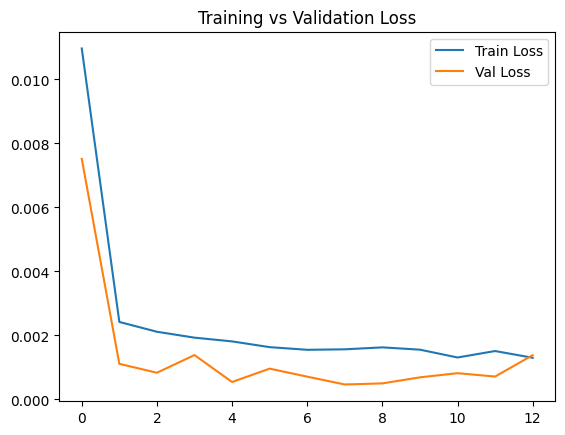

In [7]:
#Plot Training Loss

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()


In [8]:
#make prediction 
y_pred = model.predict(X_test)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step


In [9]:
from sklearn.preprocessing import MinMaxScaler
#Inverse Scaling

In [10]:
scaler = MinMaxScaler()
scaler.fit(np.concatenate((y_train.reshape(-1,1), y_test.reshape(-1,1))))

y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

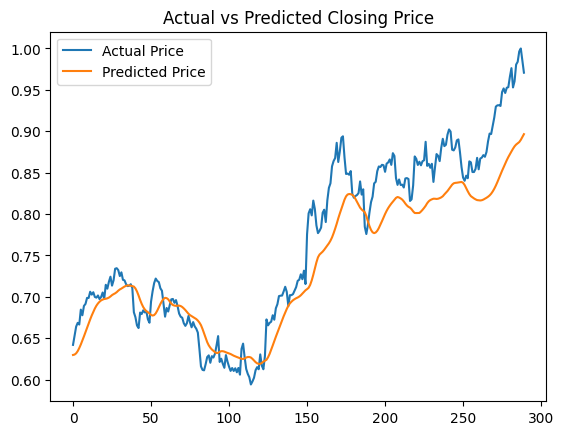

In [11]:
plt.figure()
plt.plot(y_test_inv, label="Actual Price")
plt.plot(y_pred_inv, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Closing Price")
plt.show()

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

#Evaluate the model

In [13]:
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)

rmse, mae

(np.float64(0.044186490205325814), 0.03503227489358402)

In [14]:
#save the model 
model.save("../models_saved/lstm/lstm_price_model.h5")


In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [17]:
X_train= np.load("../data/processed/X_train_feat.npy")
X_test= np.load("../data/processed/X_test_feat.npy")

y_train= np.load("../data/processed/y_train_feat.npy")
y_test= np.load("../data/processed/y_test_feat.npy")

X_train.shape,y_train.shape

((1139, 60, 10), (1139,))

In [19]:
#train the model 
model = Sequential()

model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)
model.add(Dropout(0.3))

model.add(LSTM(64))
model.add(Dropout(0.3))

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()


d:\Projects\Deep-Learning-Based-Crypto-Stock-Market-Prediction-System\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,641 (471.25 KB)

 Trainable params: 120,641 (471.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train the model

early_stop = EarlyStopping(
    monitor= "val_loss",
    patience = 1,
    restore_best_weights = True

)

history = model.fit(
    X_train,
    y_train,
    validation_split = 0.1,
    epochs = 60,
    batch_size = 32,
    callbacks = [early_stop]
)

